<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/saft_vr_mie_from_fundamental_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From quantum interactions to SAFT-VR Mie parameters and NeqSim

This executable proposal connects six open-source model layers in one reproducible workflow:

1. **PySCF** calculates an *ab initio* argon-dimer interaction curve.
2. **SciPy** maps the interaction energies to Mie parameters without fitting bulk PVT data.
3. **FEASST** executes the transferred Mie potential in an external Monte Carlo engine.
4. A second **PySCF** calculation resolves molecular orientation and estimates a water association energy.
5. **SGTPy** uses the association mapping in pure-fluid and mixture SAFT-VR Mie calculations, while **teqp** independently checks the non-associating EOS.
6. **NeqSim** receives the Mie parameters and propagates them to thermodynamic and compressor calculations.

The live quantum calculation uses CCSD(T)/aug-cc-pVDZ with counterpoise correction. It is deliberately small enough for a free Colab runtime. Its result is a **teaching-quality bottom-up estimate**, not a metrology-quality argon potential. A second route uses the literature-grade methane mapping of Walker *et al.* for the engineering hand-off. The molecular extension then demonstrates what changes when orientation and association are included instead of merely listing them as future work.


## 1. Scope, deliverables, and decision gates

| Work package | Executed deliverable | Decision gate |
|---|---|---|
| Electronic structure | Counterpoise-corrected Ar$_2$ CCSD(T) scan and oriented water-dimer MP2 calculations | Repulsion, attraction, long-range decay, and orientation sensitivity are present |
| Coarse graining | $\sigma$, $\epsilon/k_B$, $\lambda_r$, and a water association-energy estimate | Fits and mappings are unit-audited and limitations are explicit |
| Molecular simulation | FEASST two-particle Mie energy and 32-particle NVT Monte Carlo | External-engine energy matches the analytical potential and sampling is active |
| Associating fluids and mixtures | SGTPy water saturation and hexane–ethanol bubble point | Association fractions and phase-equilibrium convergence are reported |
| Independent EOS validation | Critical points, virial coefficients, and $Z(P)$ from teqp | NeqSim and teqp agree for identical non-associating parameters |
| Process use | NeqSim methane compression case | Parameter provenance reaches an engineering KPI |

**Success does not mean that a small-basis dimer calculation reproduces experiment.** Success means that every transformation is explicit, the external programs genuinely execute, units are audited, independent checks are retained, and missing physics remains visible.


## 2. Open-source stack

| Layer | Software executed here | Role |
|---|---|---|
| Quantum chemistry | [PySCF](https://pyscf.org/) | CCSD(T) argon energies and orientation-dependent MP2 water-dimer energies |
| Mapping and uncertainty | [SciPy](https://scipy.org/) | Nonlinear least squares, quadrature, roots, and bootstrap |
| Molecular simulation | [FEASST](https://pages.nist.gov/feasst/) | External Mie pair-energy verification and NVT Monte Carlo |
| Associating SAFT and mixtures | [SGTPy](https://github.com/gustavochm/sgtpy) | Association sites, saturation, unlike interactions, and binary bubble point |
| Independent SAFT implementation | [teqp](https://teqp.readthedocs.io/en/latest/models/SAFT-VR-Mie.html) | Critical point, virial, and pressure calculations |
| Engineering thermodynamics | [NeqSim](https://github.com/equinor/neqsim) | SAFT-VR Mie properties and process equipment |

All six specialist paths are executed in the notebook. FEASST is compiled from its official PyPI source distribution during setup. SGTPy is used for the association and mixture layer because its current wheel supports the Colab Python runtime. MAPSCI 0.0.3 and the current DESPASITO PyPI package were evaluated but are not claimed as executed dependencies because their published packaging is not clean on Python 3.12.


## 3. Clean Colab setup

A fresh Colab runtime installs exact versions of the three specialist packages. NumPy, SciPy, pandas, and Matplotlib are supplied by Colab. No repository checkout, local JAR, editable installation, or runtime restart is required.


In [1]:
import importlib.metadata
import importlib.util
import os
import subprocess
import sys
import time


required = {
    "numpy": "2.4.6",
    "numba": "0.66.0",
    "neqsim": "3.16.0",
    "teqp": "0.23.2",
    "pyscf": "2.14.0",
    "feasst": "0.25.19",
    "sgtpy": "0.0.23",
}

install_specs = []
for package, version in required.items():
    installed = (
        importlib.metadata.version(package)
        if importlib.util.find_spec(package) is not None
        else None
    )
    if installed != version:
        install_specs.append(f"{package}=={version}")

installation_start = time.perf_counter()
if install_specs:
    installation_environment = os.environ.copy()
    installation_environment["CMAKE_BUILD_PARALLEL_LEVEL"] = str(
        min(8, os.cpu_count() or 1)
    )
    installation_environment.setdefault("CC", "gcc")
    installation_environment.setdefault("CXX", "g++")
    installation = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-cache-dir",
            "--disable-pip-version-check",
            *install_specs,
        ],
        check=False,
        capture_output=True,
        text=True,
        env=installation_environment,
    )
    if installation.returncode != 0:
        print(installation.stdout[-4000:])
        print(installation.stderr[-4000:])
        installation.check_returncode()

installation_seconds = time.perf_counter() - installation_start
print("Specialist packages are ready:", required)
print(f"Setup elapsed time: {installation_seconds:.1f} s")


Specialist packages are ready: {'numpy': '2.4.6', 'numba': '0.66.0', 'neqsim': '3.16.0', 'teqp': '0.23.2', 'pyscf': '2.14.0', 'feasst': '0.25.19', 'sgtpy': '0.0.23'}
Setup elapsed time: 0.0 s


## 4. Imports and runtime provenance

The constants below keep energy and length conversions explicit. Pair energies are reported as $u/k_B$ in kelvin, the convention used by SAFT-VR Mie parameter tables.


In [2]:
import importlib.metadata
import json
import math
import os
import platform
import re
import shutil
import subprocess
import sys
import tempfile
import textwrap
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import teqp
from IPython.display import display
from pyscf import cc, gto, lib, mp, scf
from scipy.integrate import quad
from scipy.optimize import brentq, least_squares
from sgtpy import component, mixture, saftvrmie
from sgtpy.equilibrium import bubblePy

from neqsim import jneqsim


R = 8.31446261815324  # J mol^-1 K^-1
N_A = 6.02214076e23  # mol^-1
HARTREE_TO_K = 315775.02480407
HARTREE_TO_KJ_PER_MOL = 2625.4996394799
ANGSTROM_TO_M = 1.0e-10
RNG = np.random.default_rng(20260726)

# Some sandboxed validation runtimes hide /proc/<pid>/statm.
# Colab has it; this fallback changes only PySCF's memory estimate.
if not os.path.exists(f"/proc/{os.getpid()}/statm"):
    lib.current_memory = lambda: (0.0, 0.0)
lib.num_threads(min(2, os.cpu_count() or 1))

runtime = {
    "python": platform.python_version(),
    "java": subprocess.run(
        ["java", "-version"],
        check=True,
        capture_output=True,
        text=True,
    ).stderr.splitlines()[0],
    **{
        package: importlib.metadata.version(package)
        for package in required
    },
}
display(pd.Series(runtime, name="version"))


python                                 3.12.13
java      openjdk version "17.0.19" 2026-04-21
numpy                                    2.4.6
numba                                   0.66.0
neqsim                                  3.16.0
teqp                                    0.23.2
pyscf                                   2.14.0
feasst                                 0.25.19
sgtpy                                   0.0.23
Name: version, dtype: str

## 5. The Mie potential and the parameters to be mapped

SAFT-VR Mie uses the segment pair potential

$$
u(r)=C\epsilon\left[\left(\frac{\sigma}{r}\right)^{\lambda_r}
-\left(\frac{\sigma}{r}\right)^{\lambda_a}\right]
$$

with

$$
C=\frac{\lambda_r}{\lambda_r-\lambda_a}
\left(\frac{\lambda_r}{\lambda_a}\right)^{
\lambda_a/(\lambda_r-\lambda_a)}.
$$

Here $\sigma$ is the zero-crossing distance, $\epsilon$ is the well depth, and $\lambda_r$ and $\lambda_a$ control repulsion and attraction. For a monatomic dispersion fluid, $m=1$ and the asymptotic $r^{-6}$ form motivates $\lambda_a=6$. The remaining three parameters can be mapped from an interaction curve.

For chain molecules, $m$ is an additional coarse-graining decision. Association energies, association volumes, molecular shape, many-body interactions, and unlike-pair rules require further information; they cannot be inferred from one isotropic dimer curve.


In [3]:
def mie_constant(lambda_r, lambda_a=6.0):
    return (
        lambda_r
        / (lambda_r - lambda_a)
        * (lambda_r / lambda_a)
        ** (lambda_a / (lambda_r - lambda_a))
    )


def mie_u_over_k(r_angstrom, sigma_angstrom, epsilon_over_k,
                 lambda_r, lambda_a=6.0):
    r = np.asarray(r_angstrom, dtype=float)
    c_mie = mie_constant(lambda_r, lambda_a)
    return c_mie * epsilon_over_k * (
        (sigma_angstrom / r) ** lambda_r
        - (sigma_angstrom / r) ** lambda_a
    )


def mie_minimum(sigma_angstrom, lambda_r, lambda_a=6.0):
    return sigma_angstrom * (
        lambda_r / lambda_a
    ) ** (1.0 / (lambda_r - lambda_a))


methane_mapped = {
    "name": "Methane, potential-mapped (Walker et al.)",
    "m": 1.0,
    "sigma_angstrom": 3.7592,
    "epsilon_over_k": 170.13,
    "lambda_r": 14.440,
    "lambda_a": 6.0,
}
methane_neqsim = {
    "name": "Methane, NeqSim/Lafitte parameter set",
    "m": 1.0,
    "sigma_angstrom": 3.7412,
    "epsilon_over_k": 153.36,
    "lambda_r": 12.65,
    "lambda_a": 6.0,
}
argon_lafitte = {
    "name": "Argon, established SAFT-VR Mie set",
    "m": 1.0,
    "sigma_angstrom": 3.4016,
    "epsilon_over_k": 117.84,
    "lambda_r": 12.085,
    "lambda_a": 6.0,
}

for parameters in (methane_mapped, methane_neqsim, argon_lafitte):
    r_min = mie_minimum(
        parameters["sigma_angstrom"],
        parameters["lambda_r"],
        parameters["lambda_a"],
    )
    u_min = mie_u_over_k(
        r_min,
        parameters["sigma_angstrom"],
        parameters["epsilon_over_k"],
        parameters["lambda_r"],
        parameters["lambda_a"],
    )
    assert abs(u_min + parameters["epsilon_over_k"]) < 1.0e-9

parameter_table = pd.DataFrame(
    [
        {
            "Parameter set": p["name"],
            "m [-]": p["m"],
            "sigma [Å]": p["sigma_angstrom"],
            "epsilon/kB [K]": p["epsilon_over_k"],
            "lambda_r [-]": p["lambda_r"],
            "lambda_a [-]": p["lambda_a"],
        }
        for p in (methane_mapped, methane_neqsim, argon_lafitte)
    ]
)
display(parameter_table)


,Parameter set,m [-],sigma [Å],epsilon/kB [K],lambda_r [-],lambda_a [-]
0,"Methane, potential-mapped (Walker et al.)",1.0,3.7592,170.13,14.440,6.0
1,"Methane, NeqSim/Lafitte parameter set",1.0,3.7412,153.36,12.650,6.0
2,"Argon, established SAFT-VR Mie set",1.0,3.4016,117.84,12.085,6.0


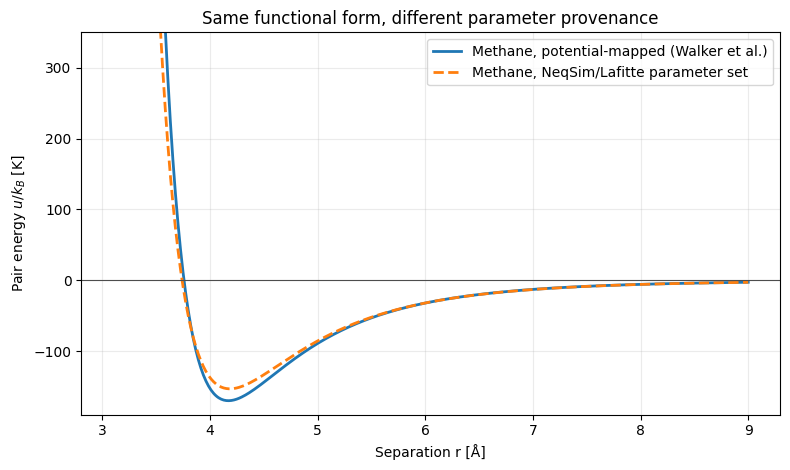

In [4]:
r_plot = np.linspace(3.1, 9.0, 500)
fig, ax = plt.subplots(figsize=(8, 4.8))
for parameters, style in [
    (methane_mapped, "-"),
    (methane_neqsim, "--"),
]:
    ax.plot(
        r_plot,
        mie_u_over_k(
            r_plot,
            parameters["sigma_angstrom"],
            parameters["epsilon_over_k"],
            parameters["lambda_r"],
            parameters["lambda_a"],
        ),
        style,
        linewidth=2,
        label=parameters["name"],
    )
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Separation r [Å]",
    ylabel=r"Pair energy $u/k_B$ [K]",
    ylim=(-190, 350),
    title="Same functional form, different parameter provenance",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Live fundamental calculation: counterpoise-corrected Ar$_2$

The interaction energy is evaluated with the Boys-Bernardi counterpoise construction

$$
\Delta E_{\mathrm{int}}(r)
=E_{\mathrm{Ar_2}}^{AB}(r)
-E_{\mathrm{Ar}}^{AB}(r)
-E_{\mathrm{Ar}}^{AB}(r).
$$

The superscript $AB$ means that both monomer basis sets are present; one atom is a ghost center in each monomer calculation. CCSD(T) captures pair correlation, but aug-cc-pVDZ is far from the complete-basis limit for weak dispersion. The scan therefore demonstrates **how** to obtain parameters and simultaneously exposes the accuracy gate.


In [5]:
def ccsdt_total_energy(atom_specification):
    molecule = gto.M(
        atom=atom_specification,
        basis="aug-cc-pvdz",
        unit="Angstrom",
        charge=0,
        spin=0,
        verbose=0,
    )
    mean_field = scf.RHF(molecule)
    mean_field.conv_tol = 1.0e-10
    mean_field.kernel()
    coupled_cluster = cc.CCSD(mean_field)
    coupled_cluster.conv_tol = 1.0e-8
    coupled_cluster.kernel()
    triples = coupled_cluster.ccsd_t()
    return (
        float(mean_field.e_tot)
        + float(coupled_cluster.e_corr)
        + float(triples)
    )


ar_distances = np.array(
    [3.0, 3.3, 3.6, 3.9, 4.2, 4.6, 5.0, 5.7, 7.0]
)
ar_interaction_k = []
scan_start = time.perf_counter()

for distance in ar_distances:
    dimer_energy = ccsdt_total_energy(
        f"Ar 0 0 0; Ar 0 0 {distance}"
    )
    monomer_energy = ccsdt_total_energy(
        f"Ar 0 0 0; ghost-Ar 0 0 {distance}"
    )
    interaction = (
        dimer_energy - 2.0 * monomer_energy
    ) * HARTREE_TO_K
    ar_interaction_k.append(interaction)
    print(
        f"r = {distance:4.1f} Å, "
        f"Delta E/kB = {interaction:9.3f} K"
    )

ar_interaction_k = np.asarray(ar_interaction_k)
scan_seconds = time.perf_counter() - scan_start
print(f"Completed {len(ar_distances)} points in {scan_seconds:.1f} s")


r =  3.0 Å, Delta E/kB =  1510.436 K
r =  3.3 Å, Delta E/kB =   352.666 K
r =  3.6 Å, Delta E/kB =    18.082 K
r =  3.9 Å, Delta E/kB =   -57.363 K
r =  4.2 Å, Delta E/kB =   -60.522 K
r =  4.6 Å, Delta E/kB =   -43.534 K
r =  5.0 Å, Delta E/kB =   -28.238 K
r =  5.7 Å, Delta E/kB =   -13.038 K
r =  7.0 Å, Delta E/kB =    -3.678 K
Completed 9 points in 76.5 s


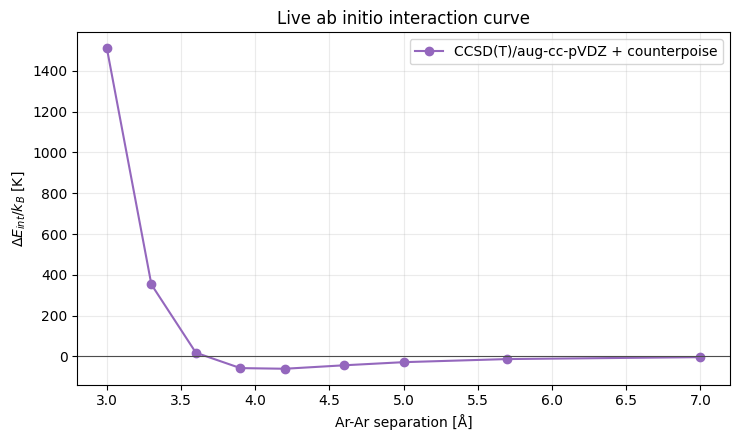

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    ar_distances,
    ar_interaction_k,
    "o-",
    color="tab:purple",
    label="CCSD(T)/aug-cc-pVDZ + counterpoise",
)
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Ar-Ar separation [Å]",
    ylabel=r"$\Delta E_{int}/k_B$ [K]",
    title="Live ab initio interaction curve",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

assert ar_interaction_k[0] > 0.0
assert np.min(ar_interaction_k) < 0.0
assert abs(ar_interaction_k[-1]) < abs(np.min(ar_interaction_k))


## 7. Map the quantum curve to Mie parameters

We hold $\lambda_a=6$ and $m=1$, then determine
$\theta=(\sigma,\epsilon/k_B,\lambda_r)$ from weighted nonlinear least squares:

$$
\hat{\theta}=\arg\min_{\theta}
\sum_i\left[
\frac{u_{\mathrm{Mie}}(r_i;\theta)-u_i^{\mathrm{QM}}}
{10\ \mathrm{K}+0.02|u_i^{\mathrm{QM}}|}
\right]^2.
$$

The scaling prevents the large repulsive energies from erasing information about the well. This is a **potential fit**, not a fit to vapor pressure, density, or critical data.


In [7]:
fit_scale = 10.0 + 0.02 * np.abs(ar_interaction_k)


def weighted_residual(parameters, distances, energies):
    sigma, epsilon_over_k, lambda_r = parameters
    prediction = mie_u_over_k(
        distances, sigma, epsilon_over_k, lambda_r, 6.0
    )
    return (prediction - energies) / (
        10.0 + 0.02 * np.abs(energies)
    )


fit = least_squares(
    weighted_residual,
    x0=np.array([3.6, 80.0, 12.0]),
    bounds=(
        np.array([2.5, 10.0, 7.0]),
        np.array([4.5, 500.0, 40.0]),
    ),
    args=(ar_distances, ar_interaction_k),
)
sigma_fit, epsilon_fit, lambda_r_fit = fit.x
ar_fundamental = {
    "name": "Argon, live CCSD(T)/small-basis map",
    "m": 1.0,
    "sigma_angstrom": sigma_fit,
    "epsilon_over_k": epsilon_fit,
    "lambda_r": lambda_r_fit,
    "lambda_a": 6.0,
}
ar_prediction = mie_u_over_k(
    ar_distances, sigma_fit, epsilon_fit, lambda_r_fit, 6.0
)
ar_rmse = float(
    np.sqrt(np.mean((ar_prediction - ar_interaction_k) ** 2))
)

degrees_of_freedom = len(ar_distances) - len(fit.x)
residual_variance = 2.0 * fit.cost / degrees_of_freedom
covariance = residual_variance * np.linalg.inv(
    fit.jac.T @ fit.jac
)
standard_errors = np.sqrt(np.diag(covariance))

mapped_table = pd.DataFrame(
    {
        "Parameter": [
            "sigma [Å]",
            "epsilon/kB [K]",
            "lambda_r [-]",
        ],
        "Estimate": fit.x,
        "Local standard error": standard_errors,
    }
)
display(mapped_table)
print(f"Unweighted energy RMSE: {ar_rmse:.2f} K")


Unweighted energy RMSE: 6.78 K


,Parameter,Estimate,Local standard error
0,sigma [Å],3.653239,0.009366
1,epsilon/kB [K],61.515500,3.179469
2,lambda_r [-],10.959536,0.286797


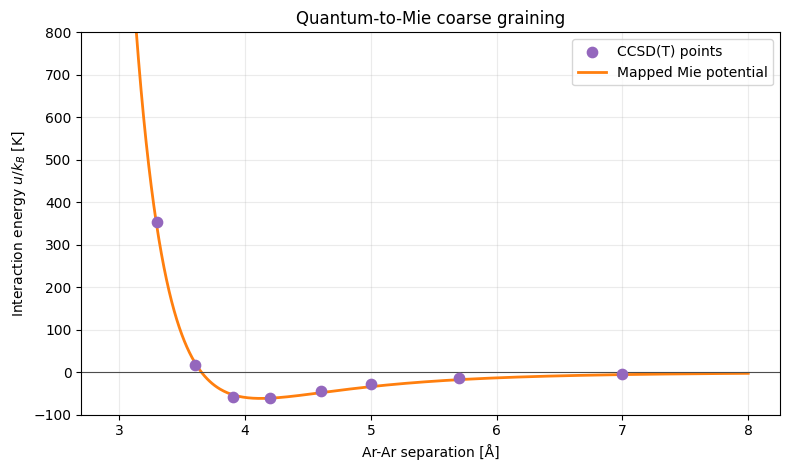

In [8]:
r_fit_plot = np.linspace(2.95, 8.0, 500)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(
    ar_distances,
    ar_interaction_k,
    s=55,
    color="tab:purple",
    label="CCSD(T) points",
    zorder=3,
)
ax.plot(
    r_fit_plot,
    mie_u_over_k(
        r_fit_plot,
        sigma_fit,
        epsilon_fit,
        lambda_r_fit,
        6.0,
    ),
    color="tab:orange",
    linewidth=2,
    label="Mapped Mie potential",
)
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Ar-Ar separation [Å]",
    ylabel=r"Interaction energy $u/k_B$ [K]",
    ylim=(-100, 800),
    title="Quantum-to-Mie coarse graining",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Accuracy interpretation

The live map isolates the numerical workflow, but it omits complete-basis extrapolation, core-valence correlation, relativistic corrections, and non-additive three-body dispersion. Those omissions are systematic and are **not** represented by the local fit covariance.

A research workflow should replace the quick scan with CCSD(T)/CBS or a validated many-body potential, add denser sampling around the zero crossing and minimum, and quantify electronic-structure/model-form uncertainty. Walker *et al.* further show how Barker-Henderson diameter and van der Waals integrals can be used in the mapping, including Axilrod-Teller and Feynman-Hibbs corrections where needed.


## 8. Statistical-mechanical checkpoint: the second virial coefficient

Directly from a pair potential,

$$
B_2(T)=-2\pi N_A\int_0^\infty
\left[\exp\left(-\frac{u(r)}{k_BT}\right)-1\right]r^2\,dr.
$$

This is the cleanest bridge between a fundamental pair potential and low-density thermodynamics. We compare the direct pair integral with teqp's SAFT-VR Mie virial prediction. They need not be identical because the analytical EOS contains approximations.


In [9]:
def pair_second_virial(T, parameters):
    sigma_m = parameters["sigma_angstrom"] * ANGSTROM_TO_M
    epsilon_over_k = parameters["epsilon_over_k"]
    lambda_r = parameters["lambda_r"]
    lambda_a = parameters["lambda_a"]
    c_mie = mie_constant(lambda_r, lambda_a)

    def dimensionless_integrand(x):
        if x < 0.04:
            return -x * x
        exponent = -c_mie * epsilon_over_k / T * (
            x ** (-lambda_r) - x ** (-lambda_a)
        )
        return np.expm1(exponent) * x * x

    integral, error = quad(
        dimensionless_integrand,
        0.0,
        50.0,
        epsabs=1.0e-10,
        epsrel=1.0e-9,
        limit=400,
    )
    return -2.0 * np.pi * N_A * sigma_m**3 * integral, error


def make_teqp_model(parameters):
    coefficient = {
        "name": parameters["name"],
        "BibTeXKey": "notebook-provenance",
        "m": parameters["m"],
        "epsilon_over_k": parameters["epsilon_over_k"],
        "sigma_m": parameters["sigma_angstrom"] * ANGSTROM_TO_M,
        "lambda_r": parameters["lambda_r"],
        "lambda_a": parameters["lambda_a"],
    }
    return teqp.make_model(
        {
            "kind": "SAFT-VR-Mie",
            "model": {"coeffs": [coefficient]},
        }
    )


methane_teqp = make_teqp_model(methane_mapped)
virial_temperatures = np.array([120.0, 150.0, 200.0, 300.0])
virial_rows = []
for temperature in virial_temperatures:
    pair_b2, _ = pair_second_virial(
        temperature, methane_mapped
    )
    saft_b2 = float(
        methane_teqp.get_dmBnvirdTm(
            2, 0, temperature, np.array([1.0])
        )
    )
    virial_rows.append(
        {
            "T [K]": temperature,
            "Pair integral B2 [cm3/mol]": pair_b2 * 1.0e6,
            "teqp SAFT B2 [cm3/mol]": saft_b2 * 1.0e6,
            "Relative difference [%]": (
                saft_b2 / pair_b2 - 1.0
            ) * 100.0,
        }
    )
virial_table = pd.DataFrame(virial_rows)
display(virial_table.round(3))


,T [K],Pair integral B2 [cm3/mol],teqp SAFT B2 [cm3/mol],Relative difference [%]
0,120.0,-267.059,-241.784,-9.464
1,150.0,-178.978,-167.256,-6.549
2,200.0,-104.987,-100.542,-4.234
3,300.0,-42.641,-41.531,-2.603


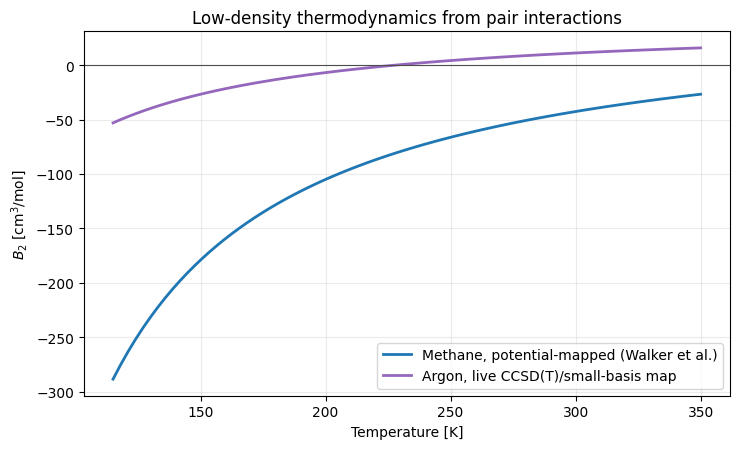

In [10]:
temperature_grid = np.linspace(115.0, 350.0, 80)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for parameters, color in [
    (methane_mapped, "tab:blue"),
    (ar_fundamental, "tab:purple"),
]:
    b2_values = [
        pair_second_virial(T, parameters)[0] * 1.0e6
        for T in temperature_grid
    ]
    ax.plot(
        temperature_grid,
        b2_values,
        color=color,
        linewidth=2,
        label=parameters["name"],
    )
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set(
    xlabel="Temperature [K]",
    ylabel=r"$B_2$ [cm$^3$/mol]",
    title="Low-density thermodynamics from pair interactions",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 9. Transparent NVT molecular simulation

The next cell runs a small canonical Metropolis simulation of single Mie sites in reduced units. It is intentionally readable: periodic boundaries, minimum-image distances, single-particle moves, and the Metropolis criterion are all visible.

This is a numerical checkpoint, not a replacement for a production simulator. Use FEASST for Gibbs-ensemble VLE, transition-matrix/flat-histogram sampling, mixture moves, finite-size studies, and reproducible long runs.


In [11]:
def reduced_mie_energy(r_reduced, lambda_r, lambda_a=6.0):
    r = np.asarray(r_reduced, dtype=float)
    return mie_constant(lambda_r, lambda_a) * (
        r ** (-lambda_r) - r ** (-lambda_a)
    )


def minimum_image(delta, box_length):
    return delta - box_length * np.rint(delta / box_length)


def particle_energy(
    particle_index, trial_position, positions, box_length,
    cutoff, lambda_r, lambda_a
):
    displacement = minimum_image(
        trial_position - positions, box_length
    )
    distances = np.linalg.norm(displacement, axis=1)
    mask = (
        (np.arange(len(positions)) != particle_index)
        & (distances < cutoff)
    )
    if not np.any(mask):
        return 0.0
    shift = reduced_mie_energy(
        cutoff, lambda_r, lambda_a
    )
    return float(
        np.sum(
            reduced_mie_energy(
                distances[mask], lambda_r, lambda_a
            )
            - shift
        )
    )


def total_reduced_energy(
    positions, box_length, cutoff, lambda_r, lambda_a
):
    energy = 0.0
    for index in range(len(positions)):
        energy += particle_energy(
            index,
            positions[index],
            positions,
            box_length,
            cutoff,
            lambda_r,
            lambda_a,
        )
    return 0.5 * energy


def run_reference_mc(
    n_particles=64,
    reduced_temperature=1.5,
    reduced_density=0.30,
    sweeps=500,
    max_displacement=0.18,
    seed=4921,
):
    rng = np.random.default_rng(seed)
    box_length = (n_particles / reduced_density) ** (1.0 / 3.0)
    side = math.ceil(n_particles ** (1.0 / 3.0))
    lattice = np.linspace(
        0.0, box_length, side, endpoint=False
    ) + box_length / (2.0 * side)
    positions = np.array(
        np.meshgrid(lattice, lattice, lattice)
    ).reshape(3, -1).T[:n_particles].copy()
    cutoff = min(3.5, box_length / 2.0)
    lambda_r = methane_mapped["lambda_r"]
    lambda_a = methane_mapped["lambda_a"]

    accepted = 0
    attempted = 0
    history = []
    for sweep in range(sweeps):
        for particle_index in rng.permutation(n_particles):
            old_position = positions[particle_index].copy()
            old_energy = particle_energy(
                particle_index,
                old_position,
                positions,
                box_length,
                cutoff,
                lambda_r,
                lambda_a,
            )
            trial_position = (
                old_position
                + rng.uniform(
                    -max_displacement,
                    max_displacement,
                    size=3,
                )
            ) % box_length
            new_energy = particle_energy(
                particle_index,
                trial_position,
                positions,
                box_length,
                cutoff,
                lambda_r,
                lambda_a,
            )
            delta_energy = new_energy - old_energy
            attempted += 1
            if (
                delta_energy <= 0.0
                or rng.random()
                < np.exp(-delta_energy / reduced_temperature)
            ):
                positions[particle_index] = trial_position
                accepted += 1

        if sweep % 5 == 0 or sweep == sweeps - 1:
            history.append(
                total_reduced_energy(
                    positions,
                    box_length,
                    cutoff,
                    lambda_r,
                    lambda_a,
                )
                / n_particles
            )

    return {
        "positions": positions,
        "box_length": box_length,
        "cutoff": cutoff,
        "acceptance": accepted / attempted,
        "energy_history": np.asarray(history),
        "temperature": reduced_temperature,
        "density": reduced_density,
    }


mc_result = run_reference_mc()
final_energy = total_reduced_energy(
    mc_result["positions"],
    mc_result["box_length"],
    mc_result["cutoff"],
    methane_mapped["lambda_r"],
    methane_mapped["lambda_a"],
) / len(mc_result["positions"])
assert np.isclose(final_energy, mc_result["energy_history"][-1])
print(
    f"Acceptance = {mc_result['acceptance']:.3f}; "
    f"final U/(N epsilon) = {final_energy:.3f}"
)


Acceptance = 0.717; final U/(N epsilon) = -1.739


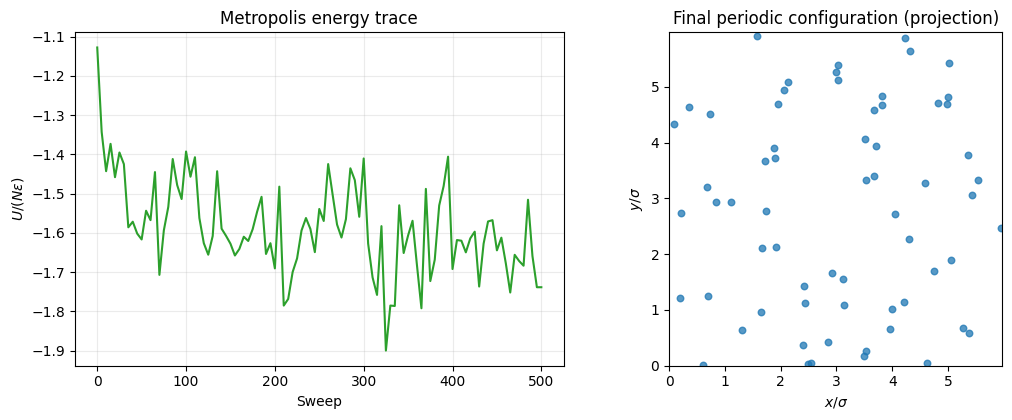

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(
    np.arange(len(mc_result["energy_history"])) * 5,
    mc_result["energy_history"],
    color="tab:green",
)
axes[0].set(
    xlabel="Sweep",
    ylabel=r"$U/(N\epsilon)$",
    title="Metropolis energy trace",
)
axes[0].grid(alpha=0.25)

axes[1].scatter(
    mc_result["positions"][:, 0],
    mc_result["positions"][:, 1],
    s=22,
    alpha=0.75,
    color="tab:blue",
)
axes[1].set(
    xlim=(0, mc_result["box_length"]),
    ylim=(0, mc_result["box_length"]),
    xlabel=r"$x/\sigma$",
    ylabel=r"$y/\sigma$",
    title="Final periodic configuration (projection)",
    aspect="equal",
)
plt.tight_layout()
plt.show()


### FEASST production hand-off

FEASST already provides SAFT-based Mie CO$_2$/N$_2$, Gibbs-ensemble, Mayer-sampling, and flat-histogram tutorials. The following machine-readable block is the parameter provenance record to translate into a FEASST particle/model input. A production study must additionally define cutoffs and long-range corrections, ensemble, system size, equilibration, uncertainty estimator, and random seeds.


In [13]:
feasst_handoff = {
    "source": "Walker et al. potential mapping, DOI 10.1063/5.0087125",
    "species": "methane",
    "sites_per_molecule": 1,
    "potential": "Mie",
    "sigma_angstrom": methane_mapped["sigma_angstrom"],
    "epsilon_over_k_K": methane_mapped["epsilon_over_k"],
    "lambda_r": methane_mapped["lambda_r"],
    "lambda_a": methane_mapped["lambda_a"],
    "recommended_workflow": [
        "Mayer sampling / B2 regression test",
        "NVT finite-size and cutoff study",
        "Gibbs or flat-histogram VLE",
        "mixture cross-parameter validation",
    ],
}
print(json.dumps(feasst_handoff, indent=2))


{
  "source": "Walker et al. potential mapping, DOI 10.1063/5.0087125",
  "species": "methane",
  "sites_per_molecule": 1,
  "potential": "Mie",
  "sigma_angstrom": 3.7592,
  "epsilon_over_k_K": 170.13,
  "lambda_r": 14.44,
  "lambda_a": 6.0,
  "recommended_workflow": [
    "Mayer sampling / B2 regression test",
    "NVT finite-size and cutoff study",
    "Gibbs or flat-histogram VLE",
    "mixture cross-parameter validation"
  ]
}


## 10. Execute the mapped potential with FEASST

The earlier NumPy Monte Carlo makes the algorithm transparent. This section now performs the independent external-library demonstration that was missing. It writes an official-format FEASST particle definition with the Walker methane parameters, asks FEASST to calculate a two-particle Mie energy, checks that value against the analytical potential, and then executes a short 32-particle NVT simulation.

The NVT run is intentionally short and dilute. It verifies parameter transfer, external-engine execution, periodic Monte Carlo sampling, long-range correction, and machine-readable result extraction. It is not a production coexistence calculation.


In [14]:
feasst_executable = shutil.which("feasst")
if feasst_executable is None:
    candidate = Path(sys.executable).parent / "feasst"
    if candidate.exists():
        feasst_executable = str(candidate)
if feasst_executable is None:
    raise FileNotFoundError("The FEASST executable is not available")

feasst_start = time.perf_counter()
with tempfile.TemporaryDirectory(prefix="neqsim_feasst_") as directory:
    run_directory = Path(directory)
    particle_file = run_directory / "methane_mie.txt"
    pair_xyz_file = run_directory / "two.xyz"
    pair_output_file = run_directory / "mie_energy.csv"
    nvt_log_file = run_directory / "nvt_log.csv"
    nvt_energy_file = run_directory / "nvt_energy.csv"

    particle_definition = f"""
    # One-site methane mapped from Walker et al.
    # Length: Angstrom; energy: Kelvin

    Site Properties

    CH4 sigma={methane_mapped["sigma_angstrom"]} \
    epsilon={methane_mapped["epsilon_over_k"]} cutoff=12.0 \
    mie_lambda_r={methane_mapped["lambda_r"]} \
    mie_lambda_a={methane_mapped["lambda_a"]}

    Sites

    CH4_1 CH4 0.0 0.0 0.0
    """
    particle_file.write_text(
        textwrap.dedent(particle_definition).strip() + "\n",
        encoding="utf-8",
    )
    pair_distance_angstrom = 4.2
    pair_xyz_file.write_text(
        (
            "2\n"
            "-1 30 30 30\n"
            "0 0.0 0.0 0.0\n"
            f"1 {pair_distance_angstrom} 0.0 0.0\n"
        ),
        encoding="utf-8",
    )

    pair_input = f"""
    MonteCarlo
    Configuration particle_type={particle_file.name} xyz_file={pair_xyz_file.name}
    Potential Model=Mie
    ThermoParams beta={1.0 / methane_mapped["epsilon_over_k"]}
    Metropolis
    Log output_file={pair_output_file.name} max_precision=true clear_file=true
    Run num_trials=1
    """
    pair_run = subprocess.run(
        [feasst_executable],
        input=textwrap.dedent(pair_input),
        cwd=run_directory,
        check=True,
        capture_output=True,
        text=True,
    )
    pair_table = pd.read_csv(pair_output_file)
    feasst_pair_energy_k = float(pair_table["Mie"].iloc[0])
    analytical_pair_energy_k = float(
        mie_u_over_k(
            pair_distance_angstrom,
            methane_mapped["sigma_angstrom"],
            methane_mapped["epsilon_over_k"],
            methane_mapped["lambda_r"],
            methane_mapped["lambda_a"],
        )
    )

    nvt_input = f"""
    MonteCarlo
    RandomMT19937 seed=20260726
    Configuration cubic_side_length=24 particle_type={particle_file.name}
    Potential Model=Mie
    Potential VisitModel=LongRangeCorrections
    ThermoParams beta={1.0 / methane_mapped["epsilon_over_k"]} \
    chemical_potential={-5.0 * methane_mapped["epsilon_over_k"]}
    Metropolis
    TrialTranslate weight=1 tunable_param=0.5
    Tune
    TrialAdd weight=2 particle_type=0
    Run until_num_particles=32 particle_type=0
    Remove name=TrialAdd
    Log trials_per_write=2000 output_file={nvt_log_file.name} clear_file=true
    Energy trials_per_write=2000 output_file={nvt_energy_file.name} clear_file=true
    Run num_trials=20000
    """
    nvt_run = subprocess.run(
        [feasst_executable],
        input=textwrap.dedent(nvt_input),
        cwd=run_directory,
        check=True,
        capture_output=True,
        text=True,
    )
    nvt_log = pd.read_csv(nvt_log_file)
    nvt_energy = pd.read_csv(nvt_energy_file)

feasst_version_line = next(
    line
    for line in pair_run.stdout.splitlines()
    if line.startswith("FEASST version")
)
feasst_pair_difference_k = abs(
    feasst_pair_energy_k - analytical_pair_energy_k
)
feasst_acceptance = float(nvt_log["TrialTranslate"].iloc[-1])
feasst_reduced_energy = float(
    nvt_energy["average"].iloc[0]
    / (32.0 * methane_mapped["epsilon_over_k"])
)
feasst_reduced_block_stdev = float(
    nvt_energy["block_stdev"].iloc[0]
    / (32.0 * methane_mapped["epsilon_over_k"])
)
feasst_seconds = time.perf_counter() - feasst_start

feasst_summary = pd.DataFrame(
    {
        "Quantity": [
            "FEASST version",
            "pair energy from FEASST [K]",
            "pair energy from analytical Mie [K]",
            "absolute pair-energy difference [K]",
            "NVT translation acceptance [-]",
            "NVT mean U/(N epsilon) [-]",
            "NVT block stdev/(N epsilon) [-]",
            "FEASST calculation time [s]",
        ],
        "Value": [
            feasst_version_line,
            feasst_pair_energy_k,
            analytical_pair_energy_k,
            feasst_pair_difference_k,
            feasst_acceptance,
            feasst_reduced_energy,
            feasst_reduced_block_stdev,
            feasst_seconds,
        ],
    }
)
display(feasst_summary)

assert feasst_pair_difference_k < 1.0e-6
assert 0.15 < feasst_acceptance < 0.80
assert np.isfinite(feasst_reduced_energy)


,Quantity,Value
0,FEASST version,FEASST version 0.25.19
1,pair energy from FEASST [K],-169.80259
2,pair energy from analytical Mie [K],-169.80259
3,absolute pair-energy difference [K],0.0
4,NVT translation acceptance [-],0.453278
5,NVT mean U/(N epsilon) [-],-0.90359
6,NVT block stdev/(N epsilon) [-],0.021288
7,FEASST calculation time [s],0.174015


## 11. Independent SAFT-VR Mie validation with teqp

teqp provides a separately implemented SAFT-VR Mie residual Helmholtz model. We use it to calculate critical points and isothermal pressures. Experimental critical constants are included only as **benchmarks**; they are never passed to the mapping optimizer.

The expected pattern is informative:

- the live small-basis argon map exposes the electronic-structure error;
- an established argon SAFT set is close to the experimental critical point;
- the directly potential-mapped methane set is predictive rather than PVT-regressed;
- the standard NeqSim/Lafitte methane set was designed for bulk-fluid performance.


In [15]:
def critical_from_teqp(parameters, temperature_guess, density_guess):
    model = make_teqp_model(parameters)
    critical_temperature, critical_density = (
        model.solve_pure_critical(
            temperature_guess, density_guess
        )
    )
    z = np.array([1.0])
    critical_z = 1.0 + float(
        model.get_Ar01(
            critical_temperature, critical_density, z
        )
    )
    critical_pressure_bar = (
        critical_density
        * R
        * critical_temperature
        * critical_z
        / 1.0e5
    )
    return (
        float(critical_temperature),
        float(critical_pressure_bar),
        float(critical_density),
    )


critical_cases = [
    (
        ar_fundamental,
        110.0,
        11000.0,
        150.687,
        48.63,
        "Argon experiment",
    ),
    (
        argon_lafitte,
        150.0,
        12500.0,
        150.687,
        48.63,
        "Argon experiment",
    ),
    (
        methane_mapped,
        195.0,
        10000.0,
        190.564,
        45.99,
        "Methane experiment",
    ),
    (
        methane_neqsim,
        190.0,
        10000.0,
        190.564,
        45.99,
        "Methane experiment",
    ),
]
critical_rows = []
for (
    parameters,
    temperature_guess,
    density_guess,
    experimental_temperature,
    experimental_pressure,
    benchmark,
) in critical_cases:
    tc, pc, rhoc = critical_from_teqp(
        parameters, temperature_guess, density_guess
    )
    critical_rows.append(
        {
            "Parameter set": parameters["name"],
            "Tc [K]": tc,
            "Pc [bar]": pc,
            "rhoc [mol/m3]": rhoc,
            "Tc error [%]": (
                tc / experimental_temperature - 1.0
            ) * 100.0,
            "Pc error [%]": (
                pc / experimental_pressure - 1.0
            ) * 100.0,
            "Benchmark": benchmark,
        }
    )
critical_table = pd.DataFrame(critical_rows)
display(critical_table.round(3))


,Parameter set,Tc [K],Pc [bar],rhoc [mol/m3],Tc error [%],Pc error [%],Benchmark
0,"Argon, live CCSD(T)/small-basis map",85.449,24.003,10103.035,-43.294,-50.643,Argon experiment
1,"Argon, established SAFT-VR Mie set",153.983,53.755,12680.893,2.187,10.539,Argon experiment
2,"Methane, potential-mapped (Walker et al.)",201.723,52.698,9609.981,5.856,14.586,Methane experiment
3,"Methane, NeqSim/Lafitte parameter set",195.155,51.320,9595.134,2.409,11.589,Methane experiment


## 12. Inject the parameters into NeqSim

NeqSim stores SAFT-VR Mie parameters on every component in every phase. Length must be passed in metres and energy as $\epsilon/k_B$ in kelvin. The helper below performs the unit conversion and updates all phase objects before the flash.


In [16]:
def build_neqsim_saft_methane(
    temperature_k, pressure_bar, parameters
):
    system = jneqsim.thermo.system.SystemSAFTVRMie(
        temperature_k, pressure_bar
    )
    system.addComponent("methane", 1.0)
    for phase_index in range(
        int(system.getMaxNumberOfPhases())
    ):
        component = (
            system.getPhase(phase_index)
            .getComponent("methane")
        )
        component.setmSAFTVRMie(parameters["m"])
        component.setSigmaSAFTVRMie(
            parameters["sigma_angstrom"] * ANGSTROM_TO_M
        )
        component.setEpsikSAFTVRMie(
            parameters["epsilon_over_k"]
        )
        component.setLambdaRSAFTVRMie(
            parameters["lambda_r"]
        )
        component.setLambdaASAFTVRMie(
            parameters["lambda_a"]
        )
    operations = (
        jneqsim.thermodynamicoperations
        .ThermodynamicOperations(system)
    )
    operations.TPflash()
    system.initProperties()
    return system


audit_system = build_neqsim_saft_methane(
    300.0, 30.0, methane_mapped
)
audit_component = (
    audit_system.getPhase(0).getComponent("methane")
)
injected_audit = pd.Series(
    {
        "m [-]": float(audit_component.getmSAFTVRMie()),
        "sigma [Å]": float(
            audit_component.getSigmaSAFTVRMie()
        )
        / ANGSTROM_TO_M,
        "epsilon/kB [K]": float(
            audit_component.getEpsikSAFTVRMie()
        ),
        "lambda_r [-]": float(
            audit_component.getLambdaRSAFTVRMie()
        ),
        "lambda_a [-]": float(
            audit_component.getLambdaASAFTVRMie()
        ),
    },
    name="Read back from NeqSim",
)
display(injected_audit)


m [-]               1.0000
sigma [Å]           3.7592
epsilon/kB [K]    170.1300
lambda_r [-]       14.4400
lambda_a [-]        6.0000
Name: Read back from NeqSim, dtype: float64

## 13. Cross-implementation pressure test

At $T=300$ K we solve the teqp pressure equation for molar density and compare its compressibility factor with NeqSim at the same pressure:

$$
P=\rho RTZ,\qquad Z=1+A_{01}^{r}.
$$

Agreement here is a strong implementation check because the parameter source and state points are identical while the software paths are independent.


In [17]:
def teqp_density_at_pressure(
    model, temperature_k, pressure_bar
):
    target_pressure = pressure_bar * 1.0e5
    composition = np.array([1.0])

    def pressure_residual(molar_density):
        z_factor = 1.0 + float(
            model.get_Ar01(
                temperature_k,
                molar_density,
                composition,
            )
        )
        return (
            molar_density * R * temperature_k * z_factor
            - target_pressure
        )

    density_scan = np.geomspace(1.0e-9, 5.0e4, 600)
    residuals = [
        pressure_residual(rho) for rho in density_scan
    ]
    for lower, upper, f_lower, f_upper in zip(
        density_scan[:-1],
        density_scan[1:],
        residuals[:-1],
        residuals[1:],
    ):
        if f_lower * f_upper <= 0.0:
            return brentq(
                pressure_residual, lower, upper
            )
    raise RuntimeError("No gas-density root was bracketed")


comparison_pressures = np.array(
    [1.0, 10.0, 30.0, 60.0, 100.0]
)
solver_rows = []
for pressure_bar in comparison_pressures:
    teqp_density = teqp_density_at_pressure(
        methane_teqp, 300.0, pressure_bar
    )
    teqp_z = 1.0 + float(
        methane_teqp.get_Ar01(
            300.0, teqp_density, np.array([1.0])
        )
    )
    neqsim_system = build_neqsim_saft_methane(
        300.0, pressure_bar, methane_mapped
    )
    neqsim_z = float(neqsim_system.getZ())
    solver_rows.append(
        {
            "P [bar]": pressure_bar,
            "teqp rho [mol/m3]": teqp_density,
            "teqp Z [-]": teqp_z,
            "NeqSim Z [-]": neqsim_z,
            "relative Z difference [%]": (
                neqsim_z / teqp_z - 1.0
            ) * 100.0,
        }
    )
solver_table = pd.DataFrame(solver_rows)
display(solver_table.round(6))


,P [bar],teqp rho [mol/m3],teqp Z [-],NeqSim Z [-],relative Z difference [%]
0,1.0,40.157628,0.998335,0.998335,-0.000024
1,10.0,407.675101,0.983400,0.983398,-0.000240
2,30.0,1265.299272,0.950545,0.950538,-0.000734
3,60.0,2664.561987,0.902755,0.902742,-0.001464
4,100.0,4733.430054,0.846971,0.846954,-0.001993


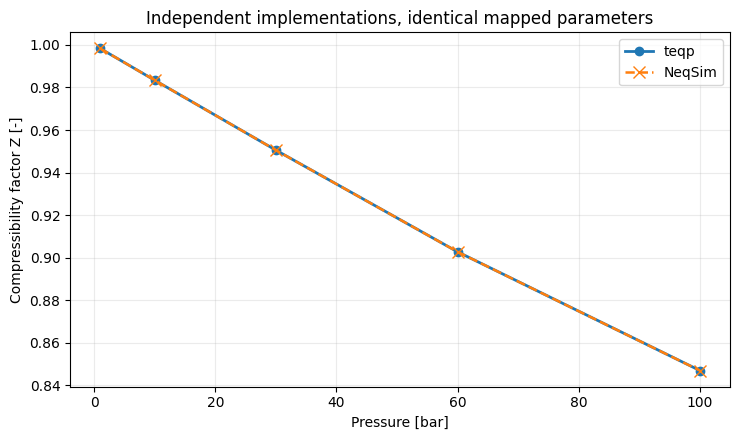

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    solver_table["P [bar]"],
    solver_table["teqp Z [-]"],
    "o-",
    linewidth=2,
    label="teqp",
)
ax.plot(
    solver_table["P [bar]"],
    solver_table["NeqSim Z [-]"],
    "x--",
    linewidth=1.8,
    markersize=8,
    label="NeqSim",
)
ax.set(
    xlabel="Pressure [bar]",
    ylabel="Compressibility factor Z [-]",
    title="Independent implementations, identical mapped parameters",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 14. Engineering propagation: methane compression

A 1 kg/s methane stream is compressed from 30 to 100 bara at 300 K with 75% isentropic efficiency. We compare the potential-mapped methane parameters with NeqSim's standard SAFT-VR Mie methane set. This is a sensitivity study, not a claim that the potential-mapped set is automatically superior for process design.


In [19]:
def run_compressor(parameters):
    fluid = build_neqsim_saft_methane(
        300.0, 30.0, parameters
    )
    inlet = jneqsim.process.equipment.stream.Stream(
        f"inlet-{parameters['name']}", fluid
    )
    inlet.setFlowRate(1.0, "kg/sec")
    inlet.run()

    compressor = (
        jneqsim.process.equipment.compressor.Compressor(
            f"compressor-{parameters['name']}", inlet
        )
    )
    compressor.setOutletPressure(100.0, "bara")
    compressor.setIsentropicEfficiency(0.75)
    compressor.run()
    outlet = compressor.getOutletStream()
    return {
        "Parameter set": parameters["name"],
        "Inlet density [kg/m3]": float(
            inlet.getFluid().getDensity("kg/m3")
        ),
        "Power [kW]": float(
            compressor.getPower("kW")
        ),
        "Outlet temperature [degC]": float(
            outlet.getTemperature("C")
        ),
    }


compressor_table = pd.DataFrame(
    [
        run_compressor(methane_neqsim),
        run_compressor(methane_mapped),
    ]
)
display(compressor_table.round(4))

power_change = (
    compressor_table.loc[1, "Power [kW]"]
    / compressor_table.loc[0, "Power [kW]"]
    - 1.0
) * 100.0
print(
    "Mapped-versus-standard compressor-power change: "
    f"{power_change:+.3f}%"
)


Mapped-versus-standard compressor-power change: -0.255%


,Parameter set,Inlet density [kg/m3],Power [kW],Outlet temperature [degC]
0,"Methane, NeqSim/Lafitte parameter set",20.2318,277.0882,149.2488
1,"Methane, potential-mapped (Walker et al.)",20.2993,276.3803,149.4329


## 15. Propagate mapping uncertainty

We resample the live quantum-curve residuals, refit the three Mie parameters, and solve each resulting argon critical point with teqp. This bootstrap represents **sampling and fit uncertainty conditional on the chosen CCSD(T)/aug-cc-pVDZ model**. It does not include the much larger basis-set, many-body, or model-form errors.


,Quantity,Median,2.5%,97.5%
0,sigma [Å],3.6581,3.6340,3.6768
1,epsilon/kB [K],59.9594,54.1910,68.5342
2,lambda_r [-],11.0573,10.6111,11.5187
3,predicted Tc [K],82.3188,73.7088,95.9576


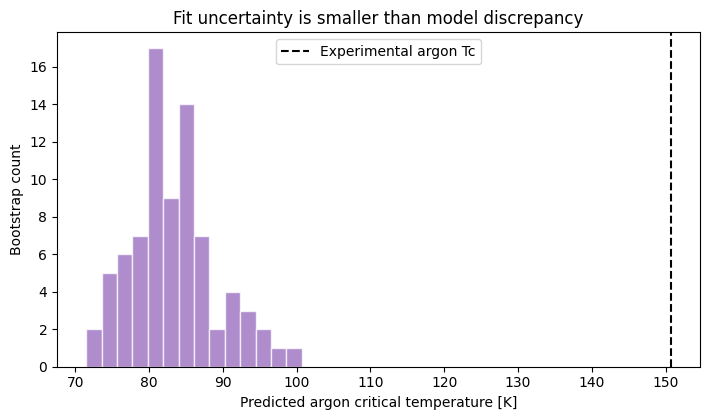

In [20]:
fitted_values = mie_u_over_k(
    ar_distances, sigma_fit, epsilon_fit, lambda_r_fit, 6.0
)
fit_residuals = ar_interaction_k - fitted_values
bootstrap_parameters = []
bootstrap_tc = []

for _ in range(80):
    synthetic_energies = (
        fitted_values
        + RNG.choice(
            fit_residuals,
            size=len(fit_residuals),
            replace=True,
        )
    )
    bootstrap_fit = least_squares(
        weighted_residual,
        x0=fit.x,
        bounds=(
            np.array([2.5, 10.0, 7.0]),
            np.array([4.5, 500.0, 40.0]),
        ),
        args=(ar_distances, synthetic_energies),
    )
    bootstrap_parameter_set = {
        "name": "Argon bootstrap",
        "m": 1.0,
        "sigma_angstrom": bootstrap_fit.x[0],
        "epsilon_over_k": bootstrap_fit.x[1],
        "lambda_r": bootstrap_fit.x[2],
        "lambda_a": 6.0,
    }
    tc, _, _ = critical_from_teqp(
        bootstrap_parameter_set, 110.0, 11000.0
    )
    bootstrap_parameters.append(bootstrap_fit.x)
    bootstrap_tc.append(tc)

bootstrap_parameters = np.asarray(bootstrap_parameters)
bootstrap_tc = np.asarray(bootstrap_tc)
uncertainty_summary = pd.DataFrame(
    {
        "Quantity": [
            "sigma [Å]",
            "epsilon/kB [K]",
            "lambda_r [-]",
            "predicted Tc [K]",
        ],
        "Median": [
            *np.median(bootstrap_parameters, axis=0),
            np.median(bootstrap_tc),
        ],
        "2.5%": [
            *np.percentile(
                bootstrap_parameters, 2.5, axis=0
            ),
            np.percentile(bootstrap_tc, 2.5),
        ],
        "97.5%": [
            *np.percentile(
                bootstrap_parameters, 97.5, axis=0
            ),
            np.percentile(bootstrap_tc, 97.5),
        ],
    }
)
display(uncertainty_summary.round(4))

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.hist(
    bootstrap_tc,
    bins=14,
    color="tab:purple",
    alpha=0.75,
    edgecolor="white",
)
ax.axvline(
    150.687,
    color="black",
    linestyle="--",
    label="Experimental argon Tc",
)
ax.set(
    xlabel="Predicted argon critical temperature [K]",
    ylabel="Bootstrap count",
    title="Fit uncertainty is smaller than model discrepancy",
)
ax.legend()
plt.tight_layout()
plt.show()


## 16. Resolve molecular orientation and association energy with PySCF

Argon is spherical, so its dimer curve cannot demonstrate molecular orientation or association. Here PySCF executes a second, genuinely molecular calculation: counterpoise-corrected MP2/aug-cc-pVDZ energies for two water-dimer orientations at the same O–O separation.

The hydrogen-bonded interaction provides a first bottom-up estimate of the SAFT association-energy scale,

$$
\frac{\epsilon^{AB}}{k_B}
\approx
-\frac{\Delta E_{\mathrm{HB}}}{R}.
$$

The sign convention makes an attractive dimer energy produce a positive association parameter. This mapping is intentionally diagnostic: a single optimized orientation does not determine the association volume or fully integrate the orientational partition function.


In [21]:
def mp2_total_energy(atom_specification):
    molecule = gto.M(
        atom=atom_specification,
        basis="aug-cc-pvdz",
        unit="Angstrom",
        charge=0,
        spin=0,
        verbose=0,
    )
    mean_field = scf.RHF(molecule)
    mean_field.conv_tol = 1.0e-10
    mean_field.kernel()
    second_order = mp.MP2(mean_field)
    second_order.kernel()
    return float(mean_field.e_tot + second_order.e_corr)


def atom_string(atoms, ghost=False):
    prefix = "ghost-" if ghost else ""
    return "; ".join(
        f"{prefix}{symbol} {x} {y} {z}"
        for symbol, (x, y, z) in atoms
    )


water_a = [
    ("O", (0.0, 0.0, 0.0)),
    ("H", (0.9572, 0.0, 0.0)),
    ("H", (-0.239987, 0.927297, 0.0)),
]
water_orientations = {
    "hydrogen-bonded": [
        ("O", (2.90, 0.0, 0.0)),
        ("H", (3.139987, 0.927297, 0.0)),
        ("H", (3.139987, -0.927297, 0.0)),
    ],
    "side-by-side": [
        ("O", (2.90, 0.0, 0.0)),
        ("H", (2.90, 0.75695, 0.58588)),
        ("H", (2.90, 0.75695, -0.58588)),
    ],
}

orientation_start = time.perf_counter()
orientation_rows = []
for orientation_name, water_b in water_orientations.items():
    dimer_atoms = (
        atom_string(water_a)
        + "; "
        + atom_string(water_b)
    )
    monomer_a_atoms = (
        atom_string(water_a)
        + "; "
        + atom_string(water_b, ghost=True)
    )
    monomer_b_atoms = (
        atom_string(water_a, ghost=True)
        + "; "
        + atom_string(water_b)
    )
    interaction_kj_per_mol = (
        mp2_total_energy(dimer_atoms)
        - mp2_total_energy(monomer_a_atoms)
        - mp2_total_energy(monomer_b_atoms)
    ) * HARTREE_TO_KJ_PER_MOL
    orientation_rows.append(
        {
            "Orientation": orientation_name,
            "O-O distance [Å]": 2.90,
            "Interaction energy [kJ/mol]": (
                interaction_kj_per_mol
            ),
        }
    )

orientation_seconds = time.perf_counter() - orientation_start
orientation_table = pd.DataFrame(orientation_rows)
hydrogen_bond_energy_kj_per_mol = float(
    orientation_table.loc[
        orientation_table["Orientation"]
        == "hydrogen-bonded",
        "Interaction energy [kJ/mol]",
    ].iloc[0]
)
side_by_side_energy_kj_per_mol = float(
    orientation_table.loc[
        orientation_table["Orientation"]
        == "side-by-side",
        "Interaction energy [kJ/mol]",
    ].iloc[0]
)
quantum_association_energy_k = (
    -hydrogen_bond_energy_kj_per_mol * 1000.0 / R
)
literature_association_energy_k = 1991.07
association_energy_difference_percent = (
    quantum_association_energy_k
    / literature_association_energy_k
    - 1.0
) * 100.0

display(orientation_table.round(4))
display(
    pd.Series(
        {
            "PySCF-derived epsilonAB/kB [K]": (
                quantum_association_energy_k
            ),
            "SGTPy water reference epsilonAB/kB [K]": (
                literature_association_energy_k
            ),
            "relative difference [%]": (
                association_energy_difference_percent
            ),
            "orientation calculation time [s]": (
                orientation_seconds
            ),
        },
        name="Association-energy mapping",
    ).round(4)
)

assert hydrogen_bond_energy_kj_per_mol < side_by_side_energy_kj_per_mol
assert 1000.0 < quantum_association_energy_k < 3000.0


,Orientation,O-O distance [Å],Interaction energy [kJ/mol]
0,hydrogen-bonded,2.9,-16.1989
1,side-by-side,2.9,-5.9087


PySCF-derived epsilonAB/kB [K]            1948.2844
SGTPy water reference epsilonAB/kB [K]    1991.0700
relative difference [%]                     -2.1489
orientation calculation time [s]             2.2905
Name: Association-energy mapping, dtype: float64

## 17. Execute associating-component and mixture calculations with SGTPy

The PySCF-derived energy is now passed into an external associating SAFT-VR Mie implementation rather than stopping at a table. SGTPy calculates water saturation at 300 K using:

1. the PySCF-derived association energy;
2. the published SGTPy association energy; and
3. the same published Mie, site topology, and association-range parameters in both cases.

The comparison with the NIST water vapour pressure shows why a dimer energy alone is not a complete parameterization. The cell then creates an associating ethanol plus non-associating hexane mixture, applies an explicit unlike $k_{ij}$, and solves a binary bubble point. Association fractions in both phases are retained as evidence that the association solver genuinely ran.


,Association route,epsilonAB/kB [K],Psat at 300 K [kPa],NIST Psat [kPa],Psat error [%],liquid unbonded-site fraction [-],vapour unbonded-site fraction [-],converged
0,PySCF-derived association energy,1948.28414,4.76031,3.5368,34.59373,0.06557,0.99782,True
1,SGTPy reference association energy,1991.06971,3.64084,3.5368,2.94168,0.06108,0.99807,True


,Quantity,Value
0,temperature [K],298.150000
1,bubble pressure [bar],0.255891
2,liquid hexane mole fraction [-],0.300000
3,vapour hexane mole fraction [-],0.732467
4,liquid association fraction 1-Xass [-],0.889734
5,vapour association fraction 1-Xass [-],0.017068
6,solver residual [-],0.000000
7,iterations [-],7.000000


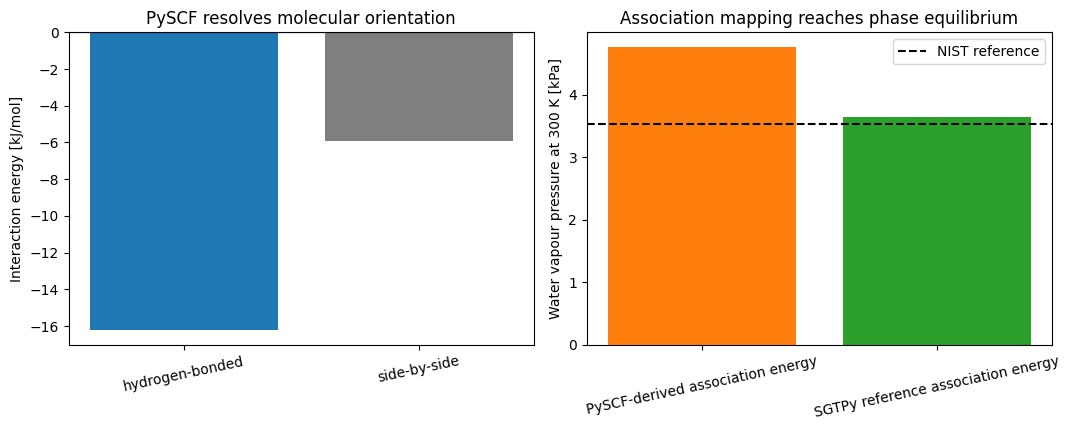

In [22]:
water_reference_pressure_pa = 3536.8
water_common = {
    "ms": 1.7311,
    "sigma": 2.4539,
    "eps": 110.85,
    "lambda_r": 8.308,
    "lambda_a": 6.0,
    "rcAB": 0.5624,
    "rdAB": 0.4,
    "sites": [0, 2, 2],
}

water_quantum = component(
    "water_quantum_association",
    eAB=quantum_association_energy_k,
    **water_common,
)
water_reference = component(
    "water_reference_association",
    eAB=literature_association_energy_k,
    **water_common,
)
water_cases = {
    "PySCF-derived association energy": water_quantum,
    "SGTPy reference association energy": water_reference,
}

saturation_rows = []
water_saturation_results = {}
for case_name, water_component in water_cases.items():
    water_eos = saftvrmie(water_component)
    saturation = water_eos.psat(
        300.0,
        full_output=True,
    )
    water_saturation_results[case_name] = saturation
    saturation_rows.append(
        {
            "Association route": case_name,
            "epsilonAB/kB [K]": water_component.eAB / (
                R / N_A
            ),
            "Psat at 300 K [kPa]": saturation.P / 1000.0,
            "NIST Psat [kPa]": (
                water_reference_pressure_pa / 1000.0
            ),
            "Psat error [%]": (
                saturation.P / water_reference_pressure_pa
                - 1.0
            )
            * 100.0,
            "liquid unbonded-site fraction [-]": float(
                np.mean(saturation.Xassl)
            ),
            "vapour unbonded-site fraction [-]": float(
                np.mean(saturation.Xassv)
            ),
            "converged": bool(saturation.success),
        }
    )
saturation_table = pd.DataFrame(saturation_rows)
display(saturation_table.round(5))

ethanol = component(
    "ethanol2C",
    ms=1.7728,
    sigma=3.5592,
    eps=224.50,
    lambda_r=11.319,
    lambda_a=6.0,
    eAB=3018.05,
    rcAB=0.3547,
    rdAB=0.4,
    sites=[1, 0, 1],
)
hexane = component(
    "hexane",
    ms=1.96720036,
    sigma=4.54762477,
    eps=377.60127994,
    lambda_r=18.41193194,
    lambda_a=6.0,
)
binary_mixture = mixture(hexane, ethanol)
binary_kij = 0.011818492037463553
binary_mixture.kij_saft(
    np.array(
        [
            [0.0, binary_kij],
            [binary_kij, 0.0],
        ]
    )
)
binary_eos = saftvrmie(binary_mixture)
liquid_composition = np.array([0.30, 0.70])
bubble_solution = bubblePy(
    liquid_composition.copy(),
    8000.0,
    liquid_composition,
    298.15,
    binary_eos,
    full_output=True,
)
binary_bubble_table = pd.DataFrame(
    {
        "Quantity": [
            "temperature [K]",
            "bubble pressure [bar]",
            "liquid hexane mole fraction [-]",
            "vapour hexane mole fraction [-]",
            "liquid association fraction 1-Xass [-]",
            "vapour association fraction 1-Xass [-]",
            "solver residual [-]",
            "iterations [-]",
        ],
        "Value": [
            bubble_solution.T,
            bubble_solution.P / 1.0e5,
            bubble_solution.X[0],
            bubble_solution.Y[0],
            1.0 - float(np.mean(bubble_solution.Xassl)),
            1.0 - float(np.mean(bubble_solution.Xassv)),
            bubble_solution.error,
            bubble_solution.iter,
        ],
    }
)
display(binary_bubble_table.round(7))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].bar(
    orientation_table["Orientation"],
    orientation_table["Interaction energy [kJ/mol]"],
    color=["tab:blue", "tab:gray"],
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set(
    ylabel="Interaction energy [kJ/mol]",
    title="PySCF resolves molecular orientation",
)
axes[0].tick_params(axis="x", rotation=12)

axes[1].bar(
    saturation_table["Association route"],
    saturation_table["Psat at 300 K [kPa]"],
    color=["tab:orange", "tab:green"],
)
axes[1].axhline(
    water_reference_pressure_pa / 1000.0,
    color="black",
    linestyle="--",
    label="NIST reference",
)
axes[1].set(
    ylabel="Water vapour pressure at 300 K [kPa]",
    title="Association mapping reaches phase equilibrium",
)
axes[1].tick_params(axis="x", rotation=12)
axes[1].legend()
plt.tight_layout()
plt.show()

assert saturation_table["converged"].all()
assert bubble_solution.error < 1.0e-8
assert bubble_solution.P > 0.0
assert np.isclose(np.sum(bubble_solution.Y), 1.0)


## 18. Remaining layers after the executable demonstrations

| Layer | Status in this notebook | Next research-grade step |
|---|---|---|
| Molecular orientation | **Executed:** two counterpoise-corrected PySCF water-dimer orientations | Sample a dense orientation and separation grid and integrate the anisotropic surface |
| Chain length $m$ | **Executed:** SGTPy segment counts for ethanol and hexane | Map molecular shape or fit structural observables from molecular simulation |
| Association | **Executed:** PySCF energy mapping and SGTPy site-based saturation | Derive association volume and site topology from a full orientational partition function |
| Unlike interactions | **Executed:** explicit SGTPy binary $k_{ij}$ and FEASST-ready mixing path | Calculate unlike dimers and compare the fitted cross potential with combining rules |
| Many-body effects | Not executed | Add three-body electronic calculations, polarizable models, or effective corrections |
| Nuclear quantum effects | Not executed | Apply Feynman–Hibbs or path-integral corrections where significant |
| Production VLE | FEASST pair energy and short NVT are executed | Run FEASST Gibbs or flat-histogram VLE with size scaling and uncertainty |

The executable examples now separate what is **calculated**, **transferred from literature**, and **still missing**. MAPSCI and DESPASITO remain relevant research paths, but they are not labelled as executed because their current published packages are not cleanly installable in the Python 3.12 Colab environment. SGTPy supplies the working association and mixture demonstration.


## 19. Automated verification summary

These checks cover units, potential normalization, quantum-curve shape, FEASST execution, molecular orientation, association mapping, mixture equilibrium, Monte Carlo bookkeeping, independent EOS agreement, and reasonable critical-point benchmarks. Passing them verifies the workflow—not the completeness of the underlying molecular physics.


In [23]:
max_solver_difference = float(
    np.max(
        np.abs(
            solver_table["relative Z difference [%]"]
        )
    )
)
checks = {
    "Mie minimum equals -epsilon": all(
        abs(
            mie_u_over_k(
                mie_minimum(
                    p["sigma_angstrom"],
                    p["lambda_r"],
                    p["lambda_a"],
                ),
                p["sigma_angstrom"],
                p["epsilon_over_k"],
                p["lambda_r"],
                p["lambda_a"],
            )
            + p["epsilon_over_k"]
        )
        < 1.0e-8
        for p in (
            methane_mapped,
            methane_neqsim,
            ar_fundamental,
        )
    ),
    "Quantum curve has repulsion and attraction": (
        ar_interaction_k[0] > 0.0
        and np.min(ar_interaction_k) < 0.0
    ),
    "Mapped parameters remain inside physical bounds": (
        2.5 < sigma_fit < 4.5
        and 10.0 < epsilon_fit < 500.0
        and 7.0 < lambda_r_fit < 40.0
    ),
    "MC acceptance is informative": (
        0.15 < mc_result["acceptance"] < 0.80
    ),
    "NeqSim and teqp Z agree within 0.01%": (
        max_solver_difference < 0.01
    ),
    "Established argon set predicts Tc within 5%": (
        abs(critical_table.loc[1, "Tc error [%]"]) < 5.0
    ),
    "Mapped methane predicts Tc within 10%": (
        abs(critical_table.loc[2, "Tc error [%]"]) < 10.0
    ),
    "Bootstrap produced finite critical points": bool(
        np.all(np.isfinite(bootstrap_tc))
    ),
    "FEASST matches the analytical pair energy": (
        feasst_pair_difference_k < 1.0e-6
    ),
    "FEASST NVT sampling is active": (
        0.15 < feasst_acceptance < 0.80
    ),
    "PySCF resolves water-dimer orientation": (
        hydrogen_bond_energy_kj_per_mol
        < side_by_side_energy_kj_per_mol
    ),
    "PySCF association-energy scale is physical": (
        1000.0 < quantum_association_energy_k < 3000.0
    ),
    "SGTPy water saturation converged": bool(
        saturation_table["converged"].all()
    ),
    "SGTPy binary bubble point converged": (
        bubble_solution.error < 1.0e-8
        and bubble_solution.P > 0.0
    ),
}
verification_table = pd.DataFrame(
    {
        "Check": list(checks),
        "Status": [
            "PASS" if result else "FAIL"
            for result in checks.values()
        ],
    }
)
display(verification_table)
assert all(checks.values()), checks
print("All executable verification checks passed.")


All executable verification checks passed.


,Check,Status
0,Mie minimum equals -epsilon,PASS
1,Quantum curve has repulsion and attraction,PASS
2,Mapped parameters remain inside physical bounds,PASS
3,MC acceptance is informative,PASS
4,NeqSim and teqp Z agree within 0.01%,PASS
5,Established argon set predicts Tc within 5%,PASS
6,Mapped methane predicts Tc within 10%,PASS
7,Bootstrap produced finite critical points,PASS
8,FEASST matches the analytical pair energy,PASS
9,FEASST NVT sampling is active,PASS


## 20. Conclusions and recommended project sequence

1. **Use this notebook now** to teach and audit the complete `PySCF → SciPy → FEASST/SGTPy/teqp → NeqSim` path.
2. **Upgrade the electronic structure** to CCSD(T)/CBS or validated many-body surfaces for both dispersion and association.
3. **Replace sparse orientation screening** with a separation–orientation grid and derive both association energy and volume.
4. **Validate low density first** with $B_2(T)$ and FEASST Mayer sampling.
5. **Validate coexistence next** with FEASST Gibbs or flat-histogram simulations and independent SAFT calculations.
6. **Calculate unlike dimers** before accepting or fitting a combining rule for mixtures.
7. **Only then propagate** frozen, versioned parameters into NeqSim process models.

The central lesson is no longer only conceptual: the notebook actually executes the external quantum-chemistry, molecular-simulation, association, mixture-EOS, independent-SAFT, and process-simulation libraries. The results also show why “fundamental” does not eliminate approximation. Electronic-structure level, coarse graining, association volume, many-body physics, EOS approximation, and process sensitivity must all remain visible.


## 21. Exercises

1. Replace aug-cc-pVDZ with aug-cc-pVTZ and quantify the changes in the argon Mie parameters and water association energy.
2. Add water-dimer separation and orientation grids; estimate an association volume rather than transferring it.
3. Compare $\lambda_r$ from least squares with a Barker–Henderson mapping.
4. Extend the FEASST run to Mayer sampling and compare $B_2(T)$ with direct quadrature.
5. Run the official FEASST Gibbs-ensemble Mie mixture tutorial with finite-size and uncertainty analysis.
6. Calculate unlike methane–argon or CO$_2$–N$_2$ dimer energies and compare a fitted cross potential with combining rules.
7. Vary SGTPy $k_{ij}$ and association energy separately to distinguish dispersion and hydrogen-bond sensitivities.
8. Add a NeqSim process state closer to the critical region and explain why parameter sensitivity increases.


## 22. References and provenance

- Walker, A. et al., “On the development of coarse-grained models for molecular fluids from *ab initio* interaction potentials,” *Journal of Chemical Physics* **156**, 154106 (2022), [DOI: 10.1063/5.0087125](https://doi.org/10.1063/5.0087125).
- Lafitte, T. et al., “Accurate statistical associating fluid theory for chain molecules formed from Mie segments,” *Journal of Chemical Physics* **139**, 154504 (2013), [DOI: 10.1063/1.4819786](https://doi.org/10.1063/1.4819786).
- Sun, Q. et al., “Recent developments in the PySCF program package,” *Journal of Chemical Physics* **153**, 024109 (2020), [DOI: 10.1063/5.0006074](https://doi.org/10.1063/5.0006074).
- Hatch, H. W. et al., “Monte Carlo simulation of cylinders with short-range attractions,” *Journal of Chemical Physics* **142**, 164105 (2015); [FEASST 0.25.19 documentation and tutorials](https://pages.nist.gov/feasst/).
- Mejía, A., Müller, E. A., and Chaparro, G., “SGTPy: A Python open-source code for calculating interfacial properties with SAFT-VR Mie,” *Journal of Chemical Information and Modeling* **61** (2021), [DOI: 10.1021/acs.jcim.0c01324](https://doi.org/10.1021/acs.jcim.0c01324).
- [teqp SAFT-VR Mie documentation](https://teqp.readthedocs.io/en/latest/models/SAFT-VR-Mie.html).
- [NeqSim source and documentation](https://github.com/equinor/neqsim).
- Experimental critical constants and water vapour pressure used as external checks: NIST Chemistry WebBook entries for [water](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7732185&Mask=4), [argon](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7440371&Mask=4) and [methane](https://webbook.nist.gov/cgi/cbook.cgi?ID=C74828&Mask=4).

Parameter provenance used in the engineering route:

- Potential-mapped methane: $\sigma=3.7592$ Å, $\epsilon/k_B=170.13$ K, $\lambda_r=14.440$, $\lambda_a=6$, $m=1$ (Walker *et al.*).
- NeqSim methane baseline read from NeqSim 3.16.0: $\sigma=3.7412$ Å, $\epsilon/k_B=153.36$ K, $\lambda_r=12.65$, $\lambda_a=6$, $m=1$.
